In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\manas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
df = pd.read_csv('spam.csv')
df = df[['Category','Message']]
df.columns = ['label','message']

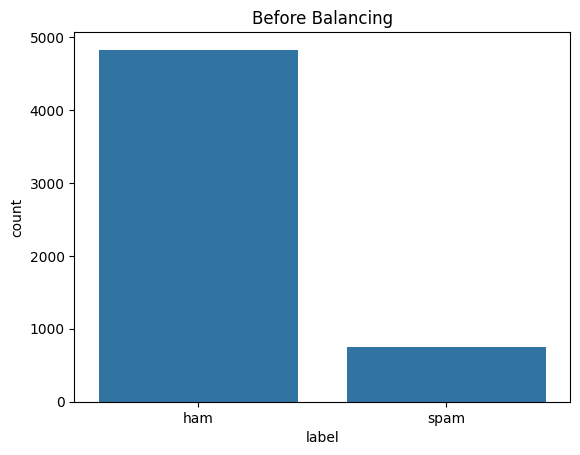

In [4]:
sns.countplot(x='label', data=df)
plt.title("Before Balancing")
plt.show()


In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()  # lowercasing
    
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URL
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove punctuation & numbers
    
    tokens = word_tokenize(text)  # tokenization
    
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

df['message'] = df['message'].apply(clean_text)


In [6]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['message']).toarray()

le = LabelEncoder()
y = le.fit_transform(df['label'])


In [7]:
df_temp = pd.DataFrame(X)
df_temp['label'] = y

df_majority = df_temp[df_temp['label'] == 0]
df_minority = df_temp[df_temp['label'] == 1]

df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42)

X_res = df_balanced.drop('label', axis=1).values
y_res = df_balanced['label'].values


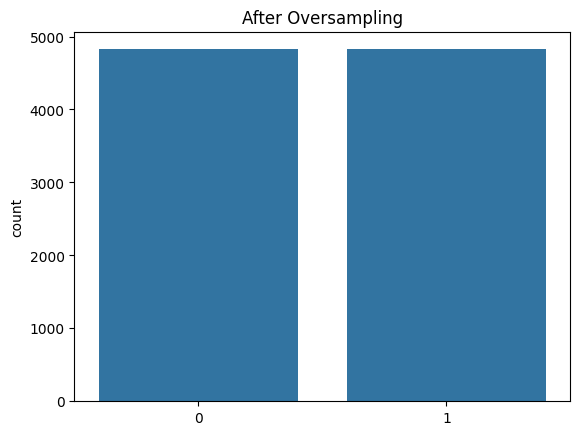

In [8]:
sns.countplot(x=y_res)
plt.title("After Oversampling")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

In [10]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=200)
nb = MultinomialNB()

# Ensemble (Voting Classifier)
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('nb', nb)
    ],
    voting='soft'
)

# Train
ensemble.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [11]:
y_pred_ens = ensemble.predict(X_test)

In [12]:
print("📊 Ensemble Accuracy:", accuracy_score(y_test, y_pred_ens))

📊 Ensemble Accuracy: 0.9953367875647668


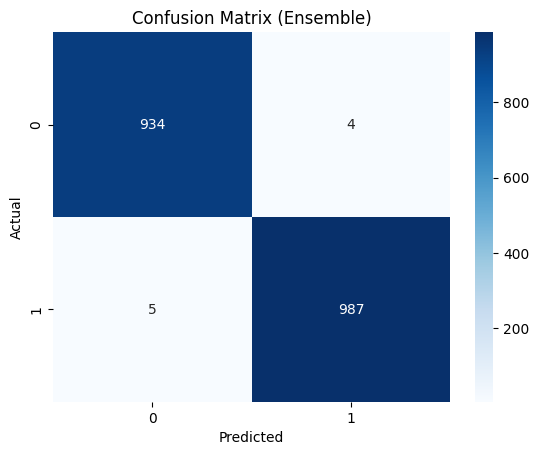

In [13]:
cm = confusion_matrix(y_test, y_pred_ens)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Ensemble)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
# ==============================
# TRAIN vs TEST ACCURACY 🔥
# ==============================

from sklearn.metrics import accuracy_score

# Train prediction
y_train_pred = ensemble.predict(X_train)

# Test prediction
y_test_pred = ensemble.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("📊 Train Accuracy:", train_acc)
print("📊 Test Accuracy :", test_acc)

📊 Train Accuracy: 0.9967616580310881
📊 Test Accuracy : 0.9953367875647668


In [15]:
def predict_spam(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    text = ' '.join(tokens)

    vector = tfidf.transform([text]).toarray()

    result = ensemble.predict(vector)

    return "Spam ❌" if result[0] == 1 else "Not Spam ✅"

In [ ]:
msg = input("Enter message: ")
print(predict_spam(msg))